# this notebook serves as the playground to learn and experiment Binning(Discretization). 
  Dataset link: https://archive.ics.uci.edu/dataset/2/adult

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [23]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv("adult.csv",header=0, names=columns,)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [24]:
df = df[['age','fnlwgt','hours_per_week','income']]
df.head()

,age,fnlwgt,hours_per_week,income
0,39,77516,40,<=50K
1,50,83311,13,<=50K
2,38,215646,40,<=50K
3,53,234721,40,<=50K
4,28,338409,40,<=50K


In [25]:
df.isnull().sum() # no missing values.
df.shape

(32561, 4)

In [26]:
X = df.drop(columns=['income'])
y = df['income']


In [27]:
df.describe()

,age,fnlwgt,hours_per_week
count,32561.000000,3.256100e+04,32561.000000
mean,38.581647,1.897784e+05,40.437456
std,13.640433,1.055500e+05,12.347429
min,17.000000,1.228500e+04,1.000000
25%,28.000000,1.178270e+05,40.000000
50%,37.000000,1.783560e+05,40.000000
75%,48.000000,2.370510e+05,45.000000
max,90.000000,1.484705e+06,99.000000


In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Fitting the model with out Binning 

In [29]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6890833717181023

In [30]:
# cross validating 
from sklearn.model_selection import cross_val_score


print("Accuracy:",np.mean(cross_val_score(clf,X,y,cv=10,scoring='accuracy')))

Accuracy: 0.6906727543548238


# Implementing Binning / Discretization

In [31]:
from sklearn.preprocessing import KBinsDiscretizer


ct = ColumnTransformer([
    ('bin_age',KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile'),['age']),
    ('bin_fnlwgt',KBinsDiscretizer(n_bins=8,encode='ordinal',strategy='quantile'),['fnlwgt'])
],remainder='passthrough')

In [32]:
X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

In [33]:
clf = DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [34]:
y_pred2 = clf.predict(X_test_transformed)
accuracy_score(y_test,y_pred2)

0.7624750499001997

In [52]:
X_transformed = ct.fit_transform(X)

In [ ]:
# cross validating again.
print("Accuracy:",np.mean(cross_val_score(clf,X_transformed,y,cv=10,scoring='accuracy'))) # make sure you enter X_transformed here during cross validation, not X.

Accuracy: 0.7607259529465548


In [37]:
ct.named_transformers_['bin_age'].n_bins_  # array([10])
ct.named_transformers_['bin_fnlwgt'].bin_edges_[0].tolist()

[12285.0,
 80058.0,
 117827.0,
 152102.0,
 178356.0,
 201105.0,
 237051.0,
 308118.0,
 1484705.0]

In [38]:
output = pd.DataFrame({
    'age': X_train['age'],
    'age_ct': X_train_transformed[:,0],
    'fnlwgt': X_train['fnlwgt'],
    'fnlwgt_ct': X_train_transformed[:,1],
    'hours_per_week': X_train['hours_per_week'],
    })
output.head(2)

,age,age_ct,fnlwgt,fnlwgt_ct,hours_per_week
5514,33,4.0,198183,4.0,50
19777,36,4.0,86459,1.0,50


In [39]:
output['age_labels'] = pd.cut(x = X_train['age'], bins = ct.named_transformers_['bin_age'].bin_edges_[0].tolist())
output['fnlwgt_labels'] = pd.cut(x = X_train['fnlwgt'], bins = ct.named_transformers_['bin_fnlwgt'].bin_edges_[0].tolist())
output


,age,age_ct,fnlwgt,fnlwgt_ct,hours_per_week,age_labels,fnlwgt_labels
5514,33,4.0,198183,4.0,50,"(30.0, 33.0]","(178356.0, 201105.0]"
19777,36,4.0,86459,1.0,50,"(33.0, 37.0]","(80058.0, 117827.0]"
10781,58,9.0,203039,5.0,40,"(50.0, 58.0]","(201105.0, 237051.0]"
32240,21,0.0,180190,4.0,46,"(17.0, 22.0]","(178356.0, 201105.0]"
9876,27,2.0,279872,6.0,40,"(26.0, 30.0]","(237051.0, 308118.0]"
...,...,...,...,...,...,...,...
29802,47,7.0,359461,7.0,40,"(45.0, 50.0]","(308118.0, 1484705.0]"
5390,31,3.0,147215,2.0,21,"(30.0, 33.0]","(117827.0, 152102.0]"
860,18,0.0,216284,5.0,20,"(17.0, 22.0]","(201105.0, 237051.0]"
15795,50,8.0,54261,0.0,84,"(45.0, 50.0]","(12285.0, 80058.0]"


# Differences of pd.cut & pd.qcut is highlighted.

In [40]:
opt = output[['age','age_ct','age_labels']]
opt['age_cut'] = pd.cut(x = X_train['age'],bins = 5)  # makes equal width bins
opt['age_qcut'] = pd.qcut(X_train['age'], q=5)        # makes equal frequency bins
opt

,age,age_ct,age_labels,age_cut,age_qcut
5514,33,4.0,"(30.0, 33.0]","(31.6, 46.2]","(26.0, 33.0]"
19777,36,4.0,"(33.0, 37.0]","(31.6, 46.2]","(33.0, 41.0]"
10781,58,9.0,"(50.0, 58.0]","(46.2, 60.8]","(50.0, 90.0]"
32240,21,0.0,"(17.0, 22.0]","(16.927, 31.6]","(16.999, 26.0]"
9876,27,2.0,"(26.0, 30.0]","(16.927, 31.6]","(26.0, 33.0]"
...,...,...,...,...,...
29802,47,7.0,"(45.0, 50.0]","(46.2, 60.8]","(41.0, 50.0]"
5390,31,3.0,"(30.0, 33.0]","(16.927, 31.6]","(26.0, 33.0]"
860,18,0.0,"(17.0, 22.0]","(16.927, 31.6]","(16.999, 26.0]"
15795,50,8.0,"(45.0, 50.0]","(46.2, 60.8]","(41.0, 50.0]"


In [41]:
opt['age_cut'].value_counts() # makes bins of equal width

age_cut
(31.6, 46.2]      9804
(16.927, 31.6]    9176
(46.2, 60.8]      5184
(60.8, 75.4]      1693
(75.4, 90.0]       191
Name: count, dtype: int64

In [42]:
opt['age_qcut'].value_counts() # makes bins of equal frequency 


age_qcut
(16.999, 26.0]    5735
(33.0, 41.0]      5432
(50.0, 90.0]      5158
(41.0, 50.0]      4921
(26.0, 33.0]      4802
Name: count, dtype: int64

# creating a function to plot before and after binning sceanrios.

In [59]:
def discretizer(Strategy,bins):
    
    ct = ColumnTransformer([
        ('bin_age',KBinsDiscretizer(strategy=Strategy,n_bins=bins,encode='ordinal'),['age','fnlwgt'])
    ],remainder='passthrough')


    clf = DecisionTreeClassifier()   
    X_transformed = ct.fit_transform(X)
    cross_val_score(clf, X_transformed,y,cv=10,scoring='accuracy')

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['age'])
    plt.title("Age Before binning")

    plt.subplot(122)
    plt.hist(X_transformed[:,0],color='red')
    plt.title("Age After binning")
    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['fnlwgt'])
    plt.title("fnlwgt before binning")


    plt.subplot(122)
    plt.hist(X_transformed[:,1],color='red')
    plt.title("fnlwgt after binning")
    plt.show()


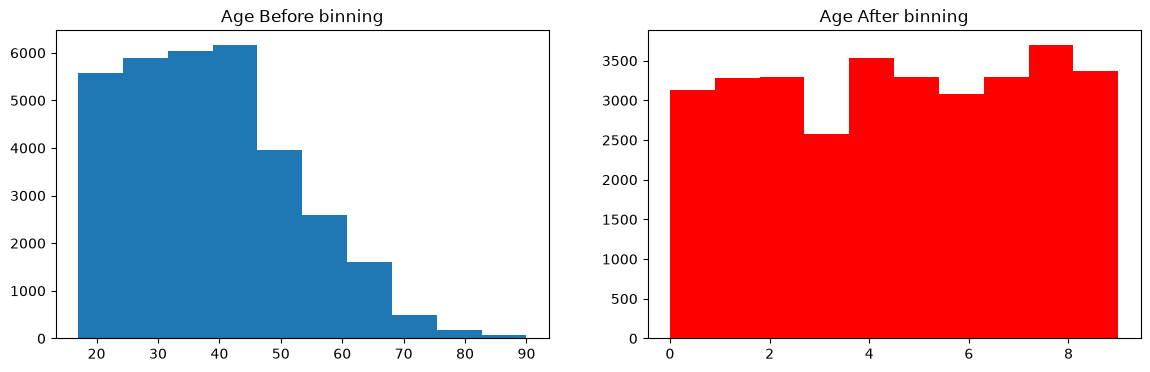

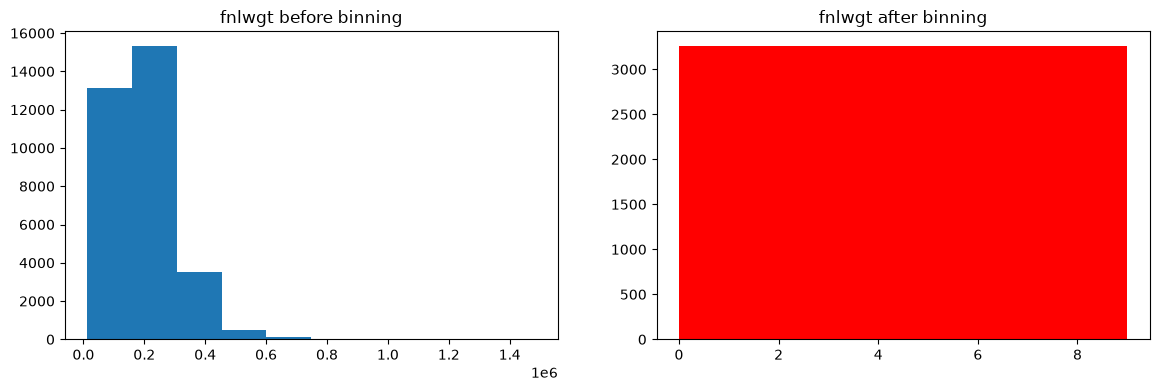

In [68]:
discretizer(Strategy = "quantile",bins=10)